# Rip-Tide 🌊
### "Buy the dip, sell the rip." It works for stocks. Does it work for oil, gold and the euro? No — and turnover is why.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Rescue by slowing down?: Busted](https://img.shields.io/badge/Rescue_by_slowing_down%3F-Busted-8b949e?style=flat-square)

This is the mirror of [Trade-Winds](../../31-trade-winds/), where *riding* the trend turned out to be a real premium. Here we do the opposite: **fade** the move — short whatever just rose, buy whatever just fell — on the very same 18 futures, with the very same machinery. Short-term reversion is a famous, real anomaly… *in individual stocks*, where it's the rent paid to whoever provides liquidity. On the world's deepest futures there's nothing to fade to begin with, and the frantic daily trading it demands turns even that nothing into a loss.

> 📓 **This is the plain-language layer.** The cost wall, the break-even, the holding-period rescue and the horizon decay are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it; the core runs on a **synthetic** mean-reverting panel, so the real-futures numbers (from [`../docs/results.md`](../docs/results.md)) are a measurement. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
sys.path.insert(0, os.path.abspath("../../.."))
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from rip_tide import data, strategy, costs, extension

# Offline synthetic control: an Ornstein-Uhlenbeck mean-reverting panel (the machinery) + a random-walk null.
# The real 18-futures verdict is in ../docs/results.md.
r, truth = data.synthetic_reversion(revert_strength=0.06, seed=32)
r0, _ = data.synthetic_reversion(revert_strength=0.0, seed=32)
print(f"synthetic control: {truth.n_markets} markets x {truth.n_days} days, revert_strength {truth.revert_strength} (null=0)")


synthetic control: 18 markets x 5040 days, revert_strength 0.06 (null=0)


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Is short-term reversion real on futures? | 🟥 **No.** Gross of *all* costs the book Sharpes **0.08** — a coin flip — and loses money in every sub-period. |
| Could you trade it anyway? | 🟥 **No.** It flips almost daily (turnover **1.38**), so it **breaks even at 0.24 bp** — cheaper than it costs to trade. Net of 2 bp: Sharpe **-0.56**. |
| Can you save it by trading slower? | ⚪ **No.** Holding longer cuts the cost *and* the (tiny) edge in lockstep — net Sharpe never gets above zero. |

> Desk shorthand: **Signal `NONE` · Tradability `MIRAGE` · Rescue? `BUSTED`** — same markets as Trade-Winds, opposite sign, opposite verdict.

## 1 · The claim 📣

The contrarian, stated at full strength (Kakushadze-Serur *151 Trading Strategies* §10.3; the academic lineage is Jegadeesh 1990, Lehmann 1990):

1. **Signal** — for each market, the *negative* sign of its own trailing 1/3/5-day return. Short if it just rose, long if it just fell.
2. **Equal risk** — divide each position by its own volatility, exactly as the trend book does.
3. **Diversify** — hold all ~18 markets across four asset classes.

The believer's case: markets overreact to short-term news and snap back, so fading the move harvests the correction. We give it the strongest possible apparatus — the one that *worked* for trend — and only flip the sign.

synthetic gross Sharpe 2.90  (null would be ~0)


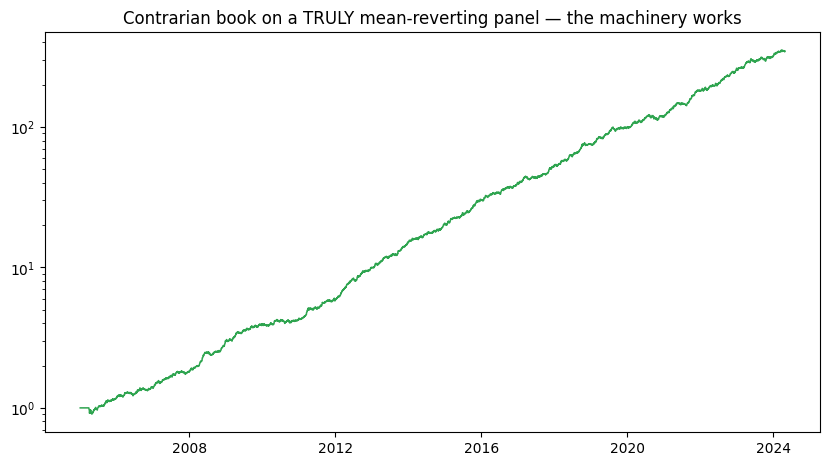

In [2]:
book = strategy.book_returns(r, cost_bps=0.0)   # GROSS, on the synthetic control
eq = (1+book).cumprod()
fig, ax = plt.subplots()
ax.plot(eq.index, eq.values, color='#2ea44f', lw=1.1)
ax.set_yscale('log'); ax.set_title('Contrarian book on a TRULY mean-reverting panel — the machinery works')
s = strategy.summary(book); print(f"synthetic gross Sharpe {s['sharpe']:.2f}  (null would be ~0)")

> 🔬 **For the quants.** On the synthetic control the price genuinely overshoots and drifts back over ~12 days, so the book earns a gross Sharpe of **2.90** (and **-0.09** on the random-walk null). The apparatus is sound — which is what makes the real-tape result a statement about *markets*, not about our code.

## 2 · So what? 💰

If liquid futures reliably overshot and snapped back, you'd have a high-Sharpe, market-neutral money machine that works in any regime — the dream of every stat-arb desk. And reversion genuinely *is* one of the most robust anomalies in equities. So the question isn't a strawman: it's whether that well-documented stock effect carries over to the deepest, most-arbitraged instruments on earth. If it doesn't, that tells you *where* the premium actually lives — in illiquidity, not in reversion per se.

## 3 · How we'd know 🔬

1. **Real?** Does the book pay *gross* of costs on the real tape, and stay flat on a random-walk null?
2. **Tradable?** Its turnover, its break-even cost, and its net Sharpe vs the dumb always-long basket.
3. **Saveable?** If it's too fast, does holding positions longer ever lift the *net* Sharpe above zero?

**Mirage line:** break-even cost below ~1 bp (what it actually costs to trade ES) — then no real account could ever collect it.

## 4 · The teardown 🔧

### 4a · The machinery works where reversion is real (control vs null)

In [3]:
for label, rr in [('reverting panel', r), ('null (random walk)', r0)]:
    s = strategy.summary(strategy.book_returns(rr, cost_bps=0.0))
    print(f"{label:22} gross Sharpe {s['sharpe']:+.2f}  turnover/day {strategy.turnover(rr):.2f}")

reverting panel        gross Sharpe +2.90  turnover/day 1.67
null (random walk)     gross Sharpe -0.09  turnover/day 1.57


### 4b · On the real tape — nothing to fade, and turnover finishes the job
On 18 real futures, 2000–2026 ([`../docs/results.md`](../docs/results.md)):

- **Gross** of all costs the book Sharpes just **0.08** (CAGR 0.2%) — a coin flip. The dumb always-long basket of the same markets Sharpes **0.51**.
- It flips almost every day: **turnover 1.38/unit per day**, so the **break-even cost is 0.24 bp** — below the ~1 bp it costs to trade the most liquid future alive.
- Net of a realistic 2 bp the Sharpe is **-0.56** with an **-88%** drawdown. A real account doesn't lose slowly here — it bleeds.

Real tape (../docs/results.md):
  contrarian gross   Sharpe 0.08   CAGR 0.2%   maxDD -51%
  contrarian net@2bp Sharpe -0.56   CAGR -6.5%   maxDD -88%
  long-only basket   Sharpe 0.51   CAGR 7.7%   maxDD -55%
  turnover/day 1.38   break-even cost 0.24 bp


Text(0.5, 1.0, 'The cost wall — reversion trades too fast to survive it')

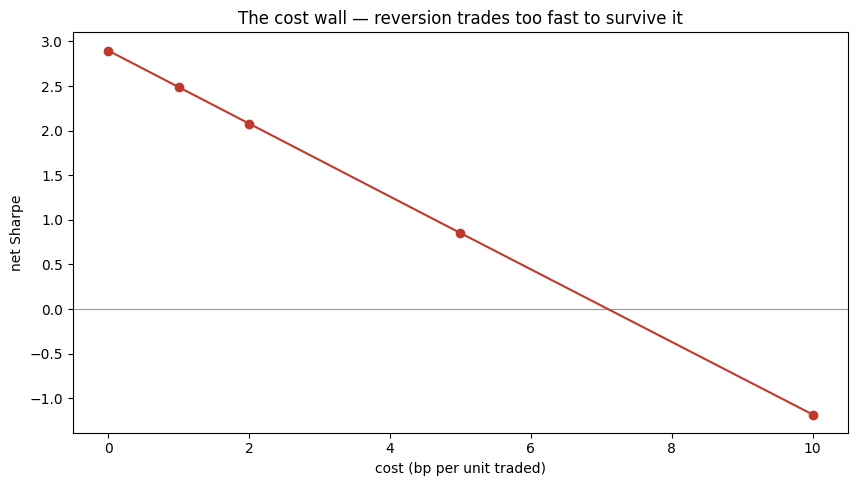

In [4]:
print('Real tape (../docs/results.md):')
print('  contrarian gross   Sharpe 0.08   CAGR 0.2%   maxDD -51%')
print('  contrarian net@2bp Sharpe -0.56   CAGR -6.5%   maxDD -88%')
print('  long-only basket   Sharpe 0.51   CAGR 7.7%   maxDD -55%')
print('  turnover/day 1.38   break-even cost 0.24 bp')
# the cost wall, drawn on the synthetic where there IS an edge to erode:
cs = costs.cost_sweep(r); 
fig, ax = plt.subplots(); ax.axhline(0, color='#999', lw=.8)
ax.plot(cs.index, cs['sharpe'], marker='o', color='#c0392b')
ax.set_xlabel('cost (bp per unit traded)'); ax.set_ylabel('net Sharpe'); ax.set_title('The cost wall — reversion trades too fast to survive it')

## 5 · The verdict 🧾

- **Signal `NONE`** — gross Sharpe 0.08 on the real tape, negative in all three sub-periods (-0.39 / -0.89 / -0.42). No premium to begin with.
- **Tradability `MIRAGE`** — turnover 1.38/day, break-even 0.24 bp, net Sharpe -0.56. Gone before the first commission.
- **Rescue `BUSTED`** — see beat 7: slowing down never lifts the net Sharpe above zero.

> **The mirror of Trade-Winds.** Same 18 futures, same machinery, opposite sign — trend is a real (fragile) premium; short-term reversion on deep futures simply is not.

## 6 · Could you trade it? 💸

- **No.** The break-even cost (0.24 bp) is *below* the real cost of trading even ES, the single most liquid future on the planet. Every realistic account loses money from day one.
- **Why it's real in stocks but not here.** Short-term reversal pays for *providing liquidity* — and it concentrates in illiquid single stocks (Avramov–Chordia–Goyal 2006; Nagel 2012). Futures this deep have no such premium left to hand out.
- **The honest takeaway.** 'Buy the dip' as a systematic, high-frequency strategy is a stock-market, small-cap phenomenon — not something you bolt onto a futures book.

## 7 · Going further 🚪

### Worked complement — "slow it down to beat the cost" ([`../docs/extension.md`](../docs/extension.md))
The book dies on turnover, so the obvious fix is to hold each position longer. We swept the holding period from 1 to 21 days on the real tape:

- Turnover falls >10× (from 1.38/day to ~0.13/day) — the cost side works perfectly.
- But the **net Sharpe never crosses zero** (-0.56 → -0.17 → -0.20). The gross edge fades exactly as fast as the cost, because there was no slow-moving reversion to harvest. `BUSTED`.
- On the synthetic control the *same* rescue keeps a net Sharpe above **1.75** even at a 21-day hold — proof the method would work if a real slow reversion existed.

### Other forks
- **Cross-sectional reversion** — fade relative winners *within* an asset class, not each market vs itself.
- **Illiquid universe** — re-run on single-stock futures / small-caps, where the liquidity premium lives.
- **Crisis-conditional** — trade reversion only when liquidity evaporates (Nagel 2012), the one time it's rich.

PRs welcome — try the cross-sectional cut, swap in an illiquid universe, or gate it on a stress signal.